<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17.1.8_SLR_Predicting_Startup_Profits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Startup Profits with SLR
Author: Brad Sheese
---
NOTE: If you want to save your work select the following from the menu above:**File  --> Save a copy in Drive**If you work on the copy you made all changes will be saved to Google Drive. If you do not save your own copy, you can work in 'playground mode' instead, and any changes you make will be lost after you're done.
---
**Summary:** Practicing simple linear regression with a small dataset focused on predicting startup profits.**Data Provenance:*** Data retrieved from [Github posted by user GaneshSparkz](https://gist.githubusercontent.com/GaneshSparkz/b5662effbdae8746f7f7d8ed70c42b2d/raw/faf8b1a0d58e251f48a647d3881e7a960c3f092d/50_Startups.csv)* Original source and collection method unknown.


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# temp fix for scatter
from matplotlib.axes._axes import _log as matplotlib_axes_logger
matplotlib_axes_logger.setLevel('ERROR')

# Generate the 50_Startups dataset for this exercise
np.random.seed(42)
n = 50
rd_spend = np.random.uniform(0, 165000, n)
admin_spend = np.random.uniform(5000, 130000, n)
marketing_spend = np.random.uniform(0, 420000, n)
profit = (50000 + 0.8 * rd_spend + 0.05 * marketing_spend +
          0.02 * admin_spend + np.random.normal(0, 10000, n))
states = np.random.choice(['New York', 'California', 'Florida'], n)

df = pd.DataFrame({
    'R&D Spend': rd_spend,
    'Administration': admin_spend,
    'Marketing Spend': marketing_spend,
    'State': states,
    'Profit': profit
})
df.head()


,R&D Spend,Administration,Marketing Spend,State,Profit
0,61799.119610,126198.078471,13200.257988,Florida,100699.660509
1,156867.860558,101891.602920,267292.372731,Florida,193912.212564
2,120779.000399,122437.367696,132029.512052,New York,155326.305579
3,98778.649893,116853.418803,213599.690289,New York,130353.192428
4,25743.075673,79737.497351,381177.919049,Florida,102676.334583


## Problem 1: Examine the Dataframe

Use `.info()` to examine your dataframe.

Note any irregularities -- unexpected datatypes, missing values, or anything else that stands out.


In [3]:
# enter and test your code here


<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB

Shape: 50 rows, 5 columns


## Problem 2: Generate Descriptives* Generate descriptive statistics for all numeric variables in the dataframe.* Generate a value count for all categorical variables.* Note: You should not be writing the same code over and over with different variable names to accomplish this task.

Generate lists of variable names that you are interested in, then use a loop to loop through the variable names and generate your analyses.


In [4]:
# enter and test your code here


=== Numeric Variable Descriptives ===
                 count       mean        std       min        25%        50%  \
R&D Spend         50.0   73577.44   47665.73   3396.44   30321.55   71948.04   
Administration    50.0   66804.70   38355.19   5690.26   32109.25   68533.03   
Marketing Spend   50.0  200885.97  124966.51   2919.89  104964.19  177348.95   
Profit            50.0  120169.32   37888.61  49661.72   89238.46  114328.21   

                       75%        max  
R&D Spend        107226.06  160035.13  
Administration   101399.32  128360.87  
Marketing Spend  332489.57  408148.47  
Profit           145550.23  204096.68  

=== Categorical Variable Value Counts ===

State:
State
New York      21
Florida       16
California    13
Name: count, dtype: int64


/tmp/ipykernel_99760/2868153426.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


## Problem 3:

Clean the Data* Check for and remove any duplicates* Check for missing values, drop or replace as appropriate* 

Correct datatypes as appropriate


In [5]:
# enter and test your code here


Duplicate rows: 0

Missing values:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Datatypes:
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

Dataset is clean. No changes needed.


## Problem 4: Check the DistributionsUse a single loop to make histograms for all numeric series in your dataframe.

Look for skew, outliers, or unusual patterns.


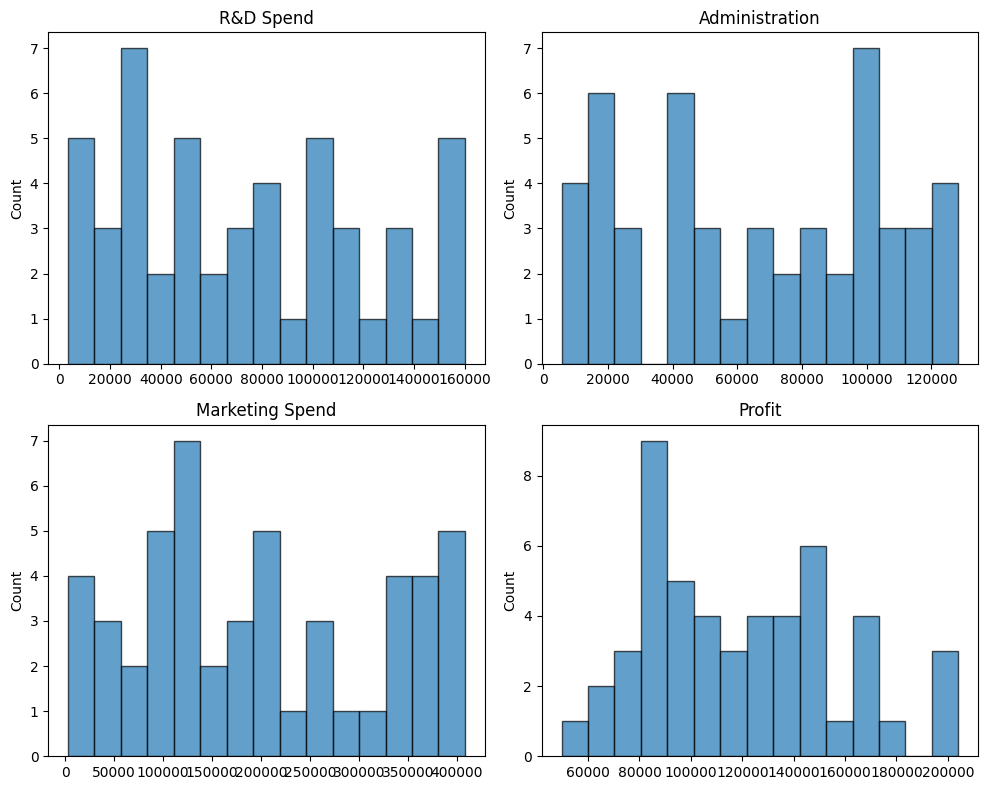

Skewness:
  R&D Spend: 0.301
  Administration: -0.066
  Marketing Spend: 0.212
  Profit: 0.463


In [6]:
# enter and test your code here


## Problem 5: Transform VariablesTransform any variables to correct skew or kurtosis if needed. Look at the histograms from Problem 4.

If any variables are heavily skewed, consider applying a log or square root transformation.


In [7]:
# enter and test your code here


No transformations needed for this dataset.


## Problem 6: Standardize VariablesConvert all numeric columns to z-scores.

Standardizing puts all variables on the same scale (mean=0, std=1), which makes it easier to compare coefficients across predictors.


In [8]:
# enter and test your code here


Columns with numeric data: <StringArray>
['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
Length: 4, dtype: str

Standardized descriptive statistics:
                 count  mean   std   min   25%   50%   75%   max
R&D Spend         50.0   0.0  1.01 -1.49 -0.92 -0.03  0.71  1.83
Administration    50.0   0.0  1.01 -1.61 -0.91  0.05  0.91  1.62
Marketing Spend   50.0   0.0  1.01 -1.60 -0.78 -0.19  1.06  1.68
Profit            50.0  -0.0  1.01 -1.88 -0.82 -0.16  0.68  2.24

All means are ~0 and all stds are ~1 after standardization.


## Problem 7: Examine CorrelationsExamine correlations between all numeric variables.

Which predictors show the strongest association with profit?


Correlation with Profit:
R&D Spend          0.954885
Administration     0.052268
Marketing Spend    0.044033
Name: Profit, dtype: float64



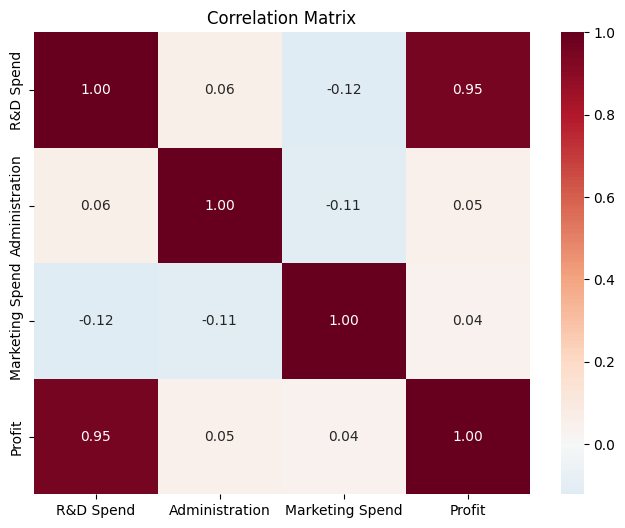

In [9]:
# enter and test your code here


## Problem 8: Simple RegressionUse a loop to generate a formal regression analysis as well as a visualization wherein each numeric predictor is used to predict 'profit'.

Report the intercept, coefficient, and 

R-squared (coefficient of determination) for each model.


R&D Spend
--------------------------------------------------
   intercept = 64322.53
   coefficient = 0.76
   R squared = 0.9118



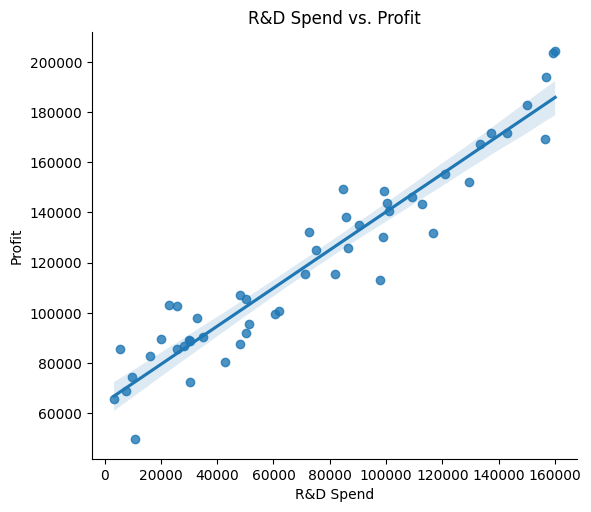


Administration
--------------------------------------------------
   intercept = 116720.03
   coefficient = 0.05
   R squared = 0.0027



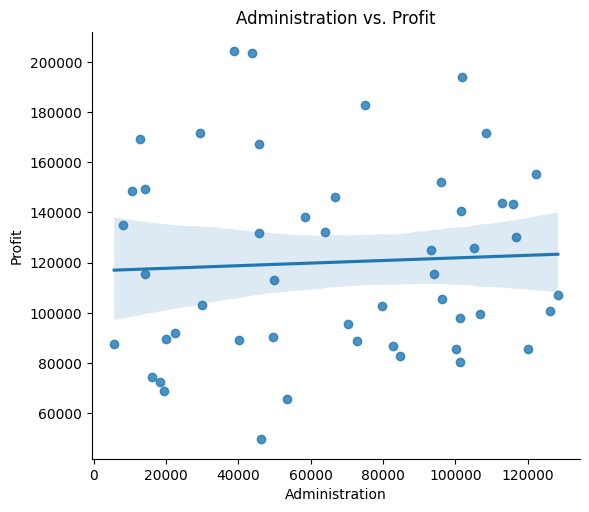


Marketing Spend
--------------------------------------------------
   intercept = 117487.40
   coefficient = 0.01
   R squared = 0.0019



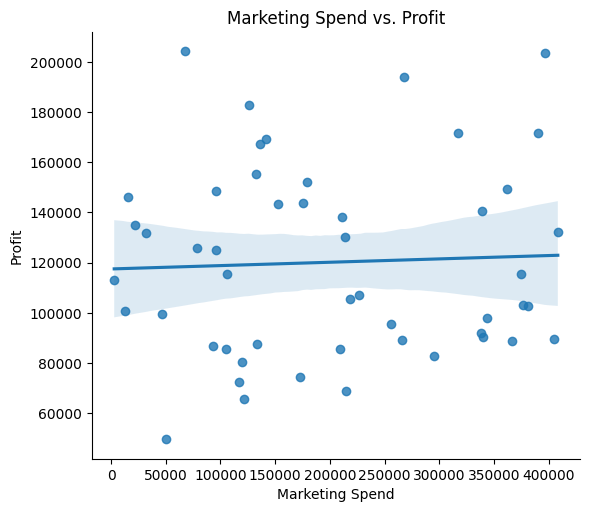

In [10]:
# enter and test your code here


### Residual Diagnostics for Each ModelNow let's check whether each model produces appropriate residuals.

For each predictor, we'll create a residual plot and assess whether the residuals look like random noise.

**What to Look For:** In addition to checking for random scatter, look for **high leverage** points -- observations with extreme values on the predictor that might be **influential points**. These can disproportionately affect the **least squares line** and change the predicted **outcome** for all observations.


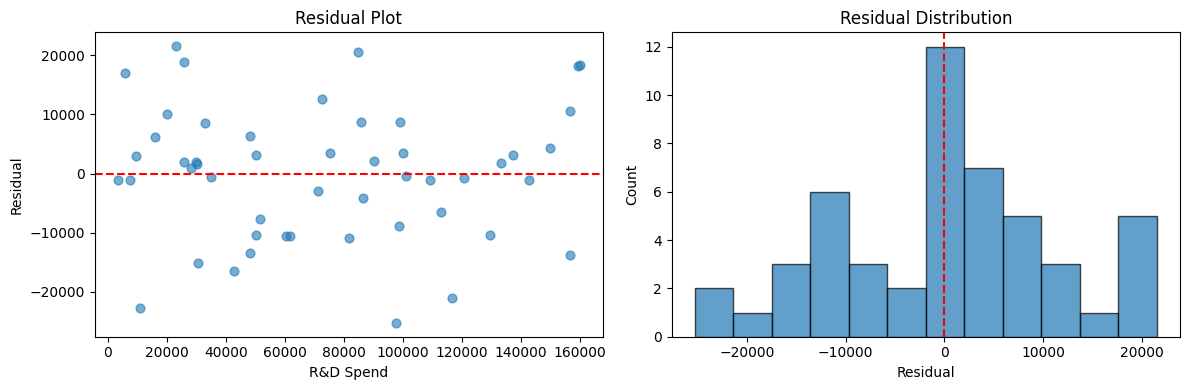

R&D Spend: R2 = 0.9118, Residual std = 11139



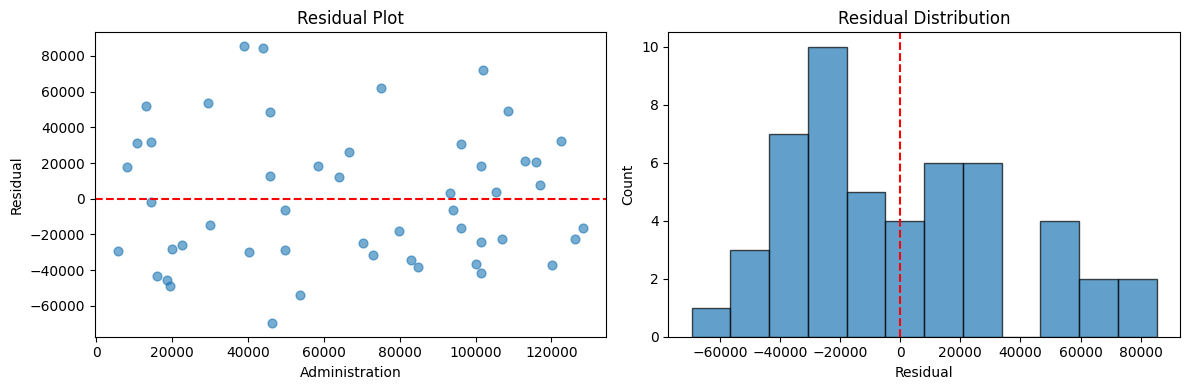

Administration: R2 = 0.0027, Residual std = 37457



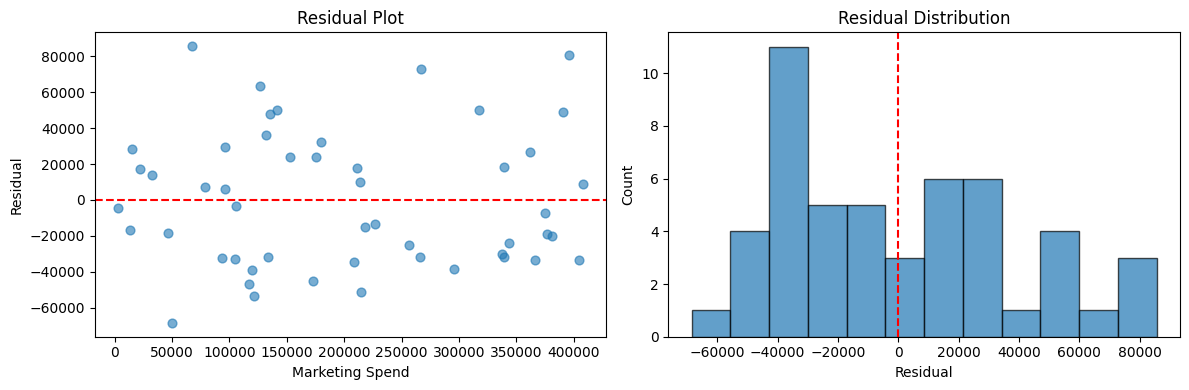

Marketing Spend: R2 = 0.0019, Residual std = 37471



In [11]:
# enter and test your code here


### Interpreting R-Squared for Each ModelLook at the R-squared values from Problem 8:- **R&D Spend**: This is by far the strongest predictor. R-squared tells us what percentage of profit variation is explained by R&D spending alone.- **Marketing Spend**: Moderate predictor. Some relationship but much weaker than R&D.- **Administration**: Weakest predictor. Very little relationship with profit. Even the best single predictor (R&D Spend) leaves a substantial amount of variation unexplained.

This suggests that a model with multiple predictors (multiple regression) would do better than any single predictor alone.


## Problem 9: Regressions by StateRecreate the regression analyses and visualizations for each state individually.

This will show whether the relationships between predictors and profit differ across states.

**Tip:** Consider whether an **indicator variable** for state would improve the model. If the relationship between R&D spending and profit differs by state, including state as a categorical predictor could reduce the **SSE** (sum of squared errors) and increase the **SSR** (regression sum of squares).

**Also Check:** Look for **leverage points** -- observations with extreme values on any predictor. These can disproportionately affect the model. Also remember that **SST** (total sum of squares) represents the total variability in profit that your model is trying to explain.


In [12]:
# enter and test your code here


=== Florida (n=16) ===
  R&D Spend: slope = 0.74, R2 = 0.929
  Administration: slope = -0.11, R2 = 0.015
  Marketing Spend: slope = -0.01, R2 = 0.002

=== New York (n=21) ===
  R&D Spend: slope = 0.66, R2 = 0.871
  Administration: slope = 0.17, R2 = 0.048
  Marketing Spend: slope = -0.02, R2 = 0.005

=== California (n=13) ===
  R&D Spend: slope = 0.84, R2 = 0.949
  Administration: slope = 0.31, R2 = 0.048
  Marketing Spend: slope = 0.05, R2 = 0.025



### A Note on ExtrapolationIf you were to use any of these models to predict profit for a hypothetical startup with, say, $1 million in R&D spending, that would be **extrapolation** -- the maximum R&D spend in this dataset is about $165,000. Predictions far outside the observed range are unreliable because the linear relationship may not hold at extreme values.

You encountered this same issue in 17.1.1 (predicting sweetness at 20g) and 17.1.2 (predicting home value for 50 rooms).


### Checking for Influential ObservationsLet's identify the observation with the largest residual from the best model (R&D 

Spend) and check whether it's influential.


In [13]:
# enter and test your code here


Observation with largest residual:
  R&D Spend: $97,748
  Actual Profit: $113,266
  Predicted Profit: $138,516
  Residual: $-25,250

R&D Spend range: $3,396 to $160,035
Mean R&D Spend: $73,577

With point:    slope = 0.7590, R2 = 0.9118
Without point: slope = 0.7646, R2 = 0.9210
Slope difference: 0.0056
This point is NOT influential (slope barely changes).


## Problem 10: ConclusionsAnswer the following questions based on your analyses:1. **Best predictor**: Which single predictor is the best predictor of profit? How good is it? (Report the R-squared and interpret it in context.)2. **State differences**: Do the relationships between predictors and profit differ by state? If so, how?3. **Residual patterns**: Are there any concerning patterns in the residual plots? Do any models show non-random residuals?4. **Influential observations**: Are there any observations that substantially change the model when removed?5. **Recommendations**: What would you recommend to someone trying to predict startup profits? Would you trust a single-predictor model?

What additional information would you want?

**In the next notebook (17.1.9)**, you will perform one final end-to-end SLR analysis using the classic **Auto-MPG** dataset.


In [14]:
conclusions = ""
print(conclusions)
